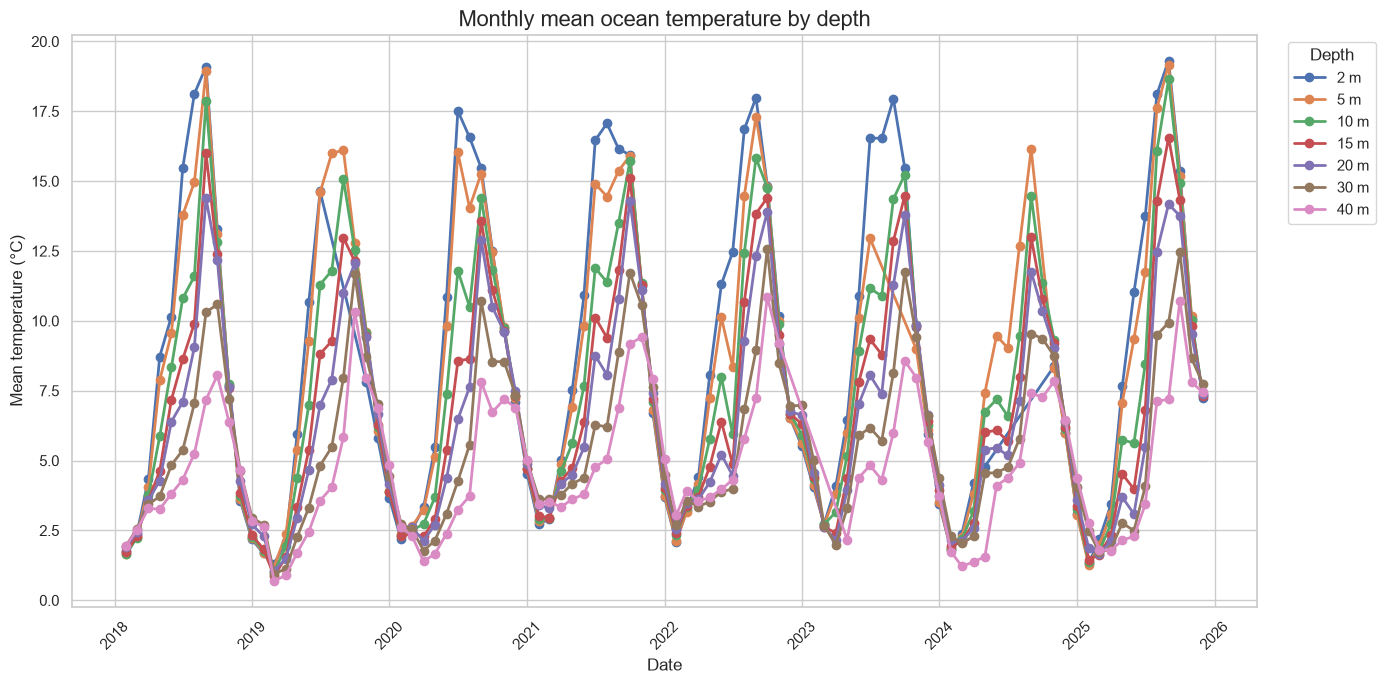

In [1]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Read the TidyTuesday ocean temperature data
df = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-03-31/ocean_temperature.csv",
    parse_dates=["date"]
)

# Clean and prepare the data
df = df.dropna(subset=["date", "sensor_depth_at_low_tide_m", "mean_temperature_degree_c"]).copy()
df["sensor_depth_at_low_tide_m"] = df["sensor_depth_at_low_tide_m"].astype(int)

# Monthly average temperature by depth
monthly = (
    df.assign(month=df["date"].dt.to_period("M").dt.to_timestamp())
      .groupby(["month", "sensor_depth_at_low_tide_m"], as_index=False)["mean_temperature_degree_c"]
      .mean()
      .sort_values(["sensor_depth_at_low_tide_m", "month"])
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 7))

for depth, group in monthly.groupby("sensor_depth_at_low_tide_m"):
    ax.plot(
        group["month"],
        group["mean_temperature_degree_c"],
        label=f"{depth} m",
        linewidth=2,
        marker="o"
    )

ax.set_title("Monthly mean ocean temperature by depth", fontsize=16)
ax.set_xlabel("Date")
ax.set_ylabel("Mean temperature (°C)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Depth", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()